# Exam Project - Introduction to Social Data Science
August 28, 2024

## Project: Forecasting Vote Counts for Danish Borgerforslag

## Group 7:
- Oliver Nyrop Weeks (vsn684)
- Sofus Galavits Møller (qvc730)
- Victor V. Kristensen (gcp458)
- Jonas T. Schmidt (mcp656)

Our baseline model is a multiple linear regression in which the target variable is threated as continuous.


Import modules.

In [ ]:
# Import modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import lemmy # !pip install lemmy
import nltk
import re



from nltk.corpus import stopwords                                           # nltk.download('stopwords')
from sklearn.model_selection import learning_curve

from sklearn.decomposition import LatentDirichletAllocation                 
from sklearn.feature_extraction.text import CountVectorizer                 
from afinn import Afinn                                                     # !pip install afinn
from sklearn.compose import make_column_selector as selector
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler, RobustScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, PoissonRegressor, Lasso
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error

import statsmodels.api as sm
from statsmodels.formula.api import glm

Set random state and maximum iterations for later calculations.

In [ ]:
random_state = 12
max_iter = 50000
test_size_globale = 1/5

Load the Dataframe and XYZ

In [ ]:
# Load DataFrame
df = pd.read_csv('data/df_after_variable.csv')
df.head()

,Title,Start Date,Votes,Body Text,Num Coauthors,Days from start to scrape,Days from start to end,Lifetime,Month_2,Month_3,...,Body Text Uppercase Count,Title Lowercase Count,Body Text Lowercase Count,Body Text LIX Score,Distance to parliament km,Big city,Title All Upper,Title has Stop,Sentiment_neutral,Sentiment_positive
0,Afskaf inklusionsloven,2024-08-15,39,For at forbedre undervisningen og sikre optima...,3,3,180,3,False,False,...,18,20,2556,59.349155,278.896623,True,False,False,False,True
1,Fartbøder forhindrer i at opnå Dansk statsborg...,2024-08-06,82,Forslaget drejer sig om regler for fartbøder v...,3,12,180,12,False,False,...,17,44,999,40.803930,355.768312,False,False,False,False,True
2,Forbyd dressurridning som konkurrencesport,2024-08-06,245,Dressurridning som konkurrencesport er en spor...,3,12,180,12,False,False,...,40,38,1864,40.113388,13.285377,False,False,False,False,False
3,Lavere skat og fjernelse af minimumsalder på p...,2024-08-06,338,Vi stiller et forslag om ændring af reglerne f...,3,12,180,12,False,False,...,14,87,1429,50.907995,291.079559,False,False,False,False,False
4,Bloddonorpligt. Som værnepligt,2024-07-26,41,Jeg forslår at der etableres en pligt til at a...,3,23,180,23,False,False,...,11,25,544,30.552941,338.944018,False,False,False,False,False


## Step 1: Latent Dirichlet Allocation

Lemmatize the documents

In [ ]:
import re

# Danish stopwords
stop = stopwords.words('danish')
extra_stopwords = ["per", "stk", "100", "2020", "begge", "uge", "50"]

for word in extra_stopwords:
    stop.append(word)

# Lemmatizer in Danish
lemmatizer = lemmy.load("da")

# Tokenization function to handle punctuation
def tokenize(text):
    return re.findall(r'\b\w+\b', text)

# Lemmatize and process each document in the "Combined Text" column
body_tokens_lem = [
    " ".join(
        [lemmatizer.lemmatize("", token.lower())[0] for token in tokenize(document) if token.lower() not in stop]
    )
    for document in df["Body Text"]
]

# Print the first few rows to verify
print("Lemmatized Tokens:", body_tokens_lem[0])



Lemmatized Tokens: forbedre undervisning sikre optimal støtte elevere særlig behov foreslå afskaffe inklusionslov stede genindføre styrke specialtilbud folkeskole indebære omlægning ressource se flere middel afsætte specialskole specialklasse elevere særlig behov kunne få skræddersy undervisning støtte uddanne specialist desuden etablere flere fleksibel ordning elevere kunne modtage kombination specialpædagogisk støtte undervisning almindelig klasse hensigtsmæssig udvikling sikre få nødvendig faglig social støtte samtidig højere grade inkludere skole fællesskab præmis lære kompetence burde opgradere gennem efteruddannelse se god ruste identificere håndtere elevere særlig behov desuden burde etablere stærk samarbejdsstrukturere mellem lærer pædagog specialist sikre helhedsorienteret tilgang hver enkel elev behov ændring sikre elevere modtage undervisning støtte niveau god fremme læring trivsel lære kunne fokusere lever høj undervisningskvalitet inklusionslov indføre 2012 formål inkluder

In [ ]:
# To test added stopwords
#unique = set(stop) 
#print("How many unqiue stopwords: ", len(unique))
#print("and how many total stopwords: ", len(stop))

In [ ]:
# Splitting string dataset into development- and test data.
body_dev, body_test = train_test_split(body_tokens_lem, test_size=test_size_globale, random_state=random_state)
body_dev_title, body_test_title = train_test_split(df["Title"], test_size=test_size_globale, random_state=random_state)

# Set min_df to 3, max_df to 0.1 for bag of words
count = CountVectorizer(min_df=3, max_df=0.1, max_features=50000)
bag = count.fit_transform(body_dev)

# Define the unsupervised machine learning model
lda = LatentDirichletAllocation(n_components=9, random_state=123)
borgerforslag_topics = lda.fit_transform(bag)

# Displaying topics
n_top_words = 7
word_names = count.get_feature_names_out()
for topic_idx, topic in enumerate(lda.components_):
    print("Topic %d:" % (topic_idx + 1))
    print(" ".join([word_names[i] for i in topic.argsort()[:-n_top_words - 1:-1]]))

# Assign the most relevant topic to each document in the development set
doc_labels = []
for i, topic_dist in enumerate(borgerforslag_topics):
    document_title = body_dev_title.iloc[i]
    most_probable_topic = np.argmax(topic_dist) + 1  # Select only the most probable topic
    if topic_dist[most_probable_topic - 1] > 0.1:  # Apply threshold if needed
        doc_labels.append((document_title, most_probable_topic))

Topic 1:
køre parti bile co2 israel valg ukraine
Topic 2:
kvinde behandling skole syg sygdom psykisk mand
Topic 3:
skatte eu virksomhed pension per pensionist produkt
Topic 4:
socialrådgiver digital fejle autorisation europæisk udføre straffe
Topic 5:
uddannelse undervisning studerende elevere elev eksamen transport
Topic 6:
behandling straffe virksomhed gammel cannabis time risiko
Topic 7:
politisk who mand mediere hest politiker statsminister
Topic 8:
dy hund natur grøn fyrværkeri eu meter
Topic 9:
politi myndighed virksomhed statsborgerskab bolig flygtning vurdering


Below we predict catagories on lda trained on body_dev

In [ ]:
# Process the test set
bag_test = count.transform(body_test)
borgerforslag_topics_test = lda.transform(bag_test)

# Assign the most relevant topic to each document in the test set
doc_labels_test = []
for i, topic_dist in enumerate(borgerforslag_topics_test):
    document_title = body_test_title.iloc[i]
    most_probable_topic = np.argmax(topic_dist) + 1  # Select only the most probable topic
    if topic_dist[most_probable_topic - 1] > 0.1:  # Apply threshold if needed
        doc_labels_test.append((document_title, most_probable_topic))


We now create dummies and add as variables to df

In [ ]:
# Creating and concatenating DataFrames
merged_topics = pd.concat(
    [pd.DataFrame(doc_labels, columns=['Title', 'Topic']),
     pd.DataFrame(doc_labels_test, columns=['Title', 'Topic'])],
    ignore_index=True
)

# Merge df with merged_topics on 'Title' and create dummies for the topics
df = pd.merge(df, merged_topics, on='Title', how='left').drop(columns='Topic')

# Add dummy variables for topics directly after merging
df = df.join(pd.get_dummies(merged_topics['Topic'], drop_first=True, prefix="Topic"))

# Display the first row of the updated DataFrame
df.head(1)


,Title,Start Date,Votes,Body Text,Num Coauthors,Days from start to scrape,Days from start to end,Lifetime,Month_2,Month_3,...,Sentiment_neutral,Sentiment_positive,Topic_2,Topic_3,Topic_4,Topic_5,Topic_6,Topic_7,Topic_8,Topic_9
0,Afskaf inklusionsloven,2024-08-15,39,For at forbedre undervisningen og sikre optima...,3,3,180,3,False,False,...,False,True,False,False,True,False,False,False,False,False


## Step 2: Overview of Data

Create a function for scatterplots.

In [ ]:
# Create a pd.series for the target
target = df['Votes']

# Create second pd.sereies for log target
import math
log_target = [math.log10(signatures) for signatures in target]

# Drop target from df
df = df.drop(columns=['Votes', 
                      'Distance to parliament km'])

# Create selectors for numerical and categorical features
num_cols_sel = selector(dtype_include='number')
cat_cols_sel = selector(dtype_include='bool')

# Create numerical and categorical features
num_cols = num_cols_sel(df)
cat_cols = cat_cols_sel(df)

In [ ]:
# Function for scatterplots
def scatterplot(df: pd.DataFrame, target: pd.Series, features: list, cols: int = 3):

    # Determine the number of features and rows needed for the subplot grid
    num_features = len(features)
    rows = (num_features + cols - 1) // cols
    
    # Create figure and axes
    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 5 * rows))
    
    # Flatten the axes array if there are multiple rows or columns
    axes = axes.flatten() if rows > 1 or cols > 1 else [axes]
    
    # Loop through each feature and create a scatterplot
    for i, feature in enumerate(features):
        # Plot the scatterplot with seaborn
        sns.scatterplot(x=df[feature], y=target, ax=axes[i])
        
        # Set the title for the current subplot
        axes[i].set_title(f'{feature} vs {target.name}')
        
        # Label the x-axis with the feature name
        axes[i].set_xlabel(feature)
        
        # Label the y-axis with the target name
        axes[i].set_ylabel(target.name)
    
    # Hide any unused subplots if the number of features is less than the number of grid spaces
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')
    
    # Show the scatterplot
    plt.tight_layout()
    
    plt.show();

Create scatterplots for all numeric features.

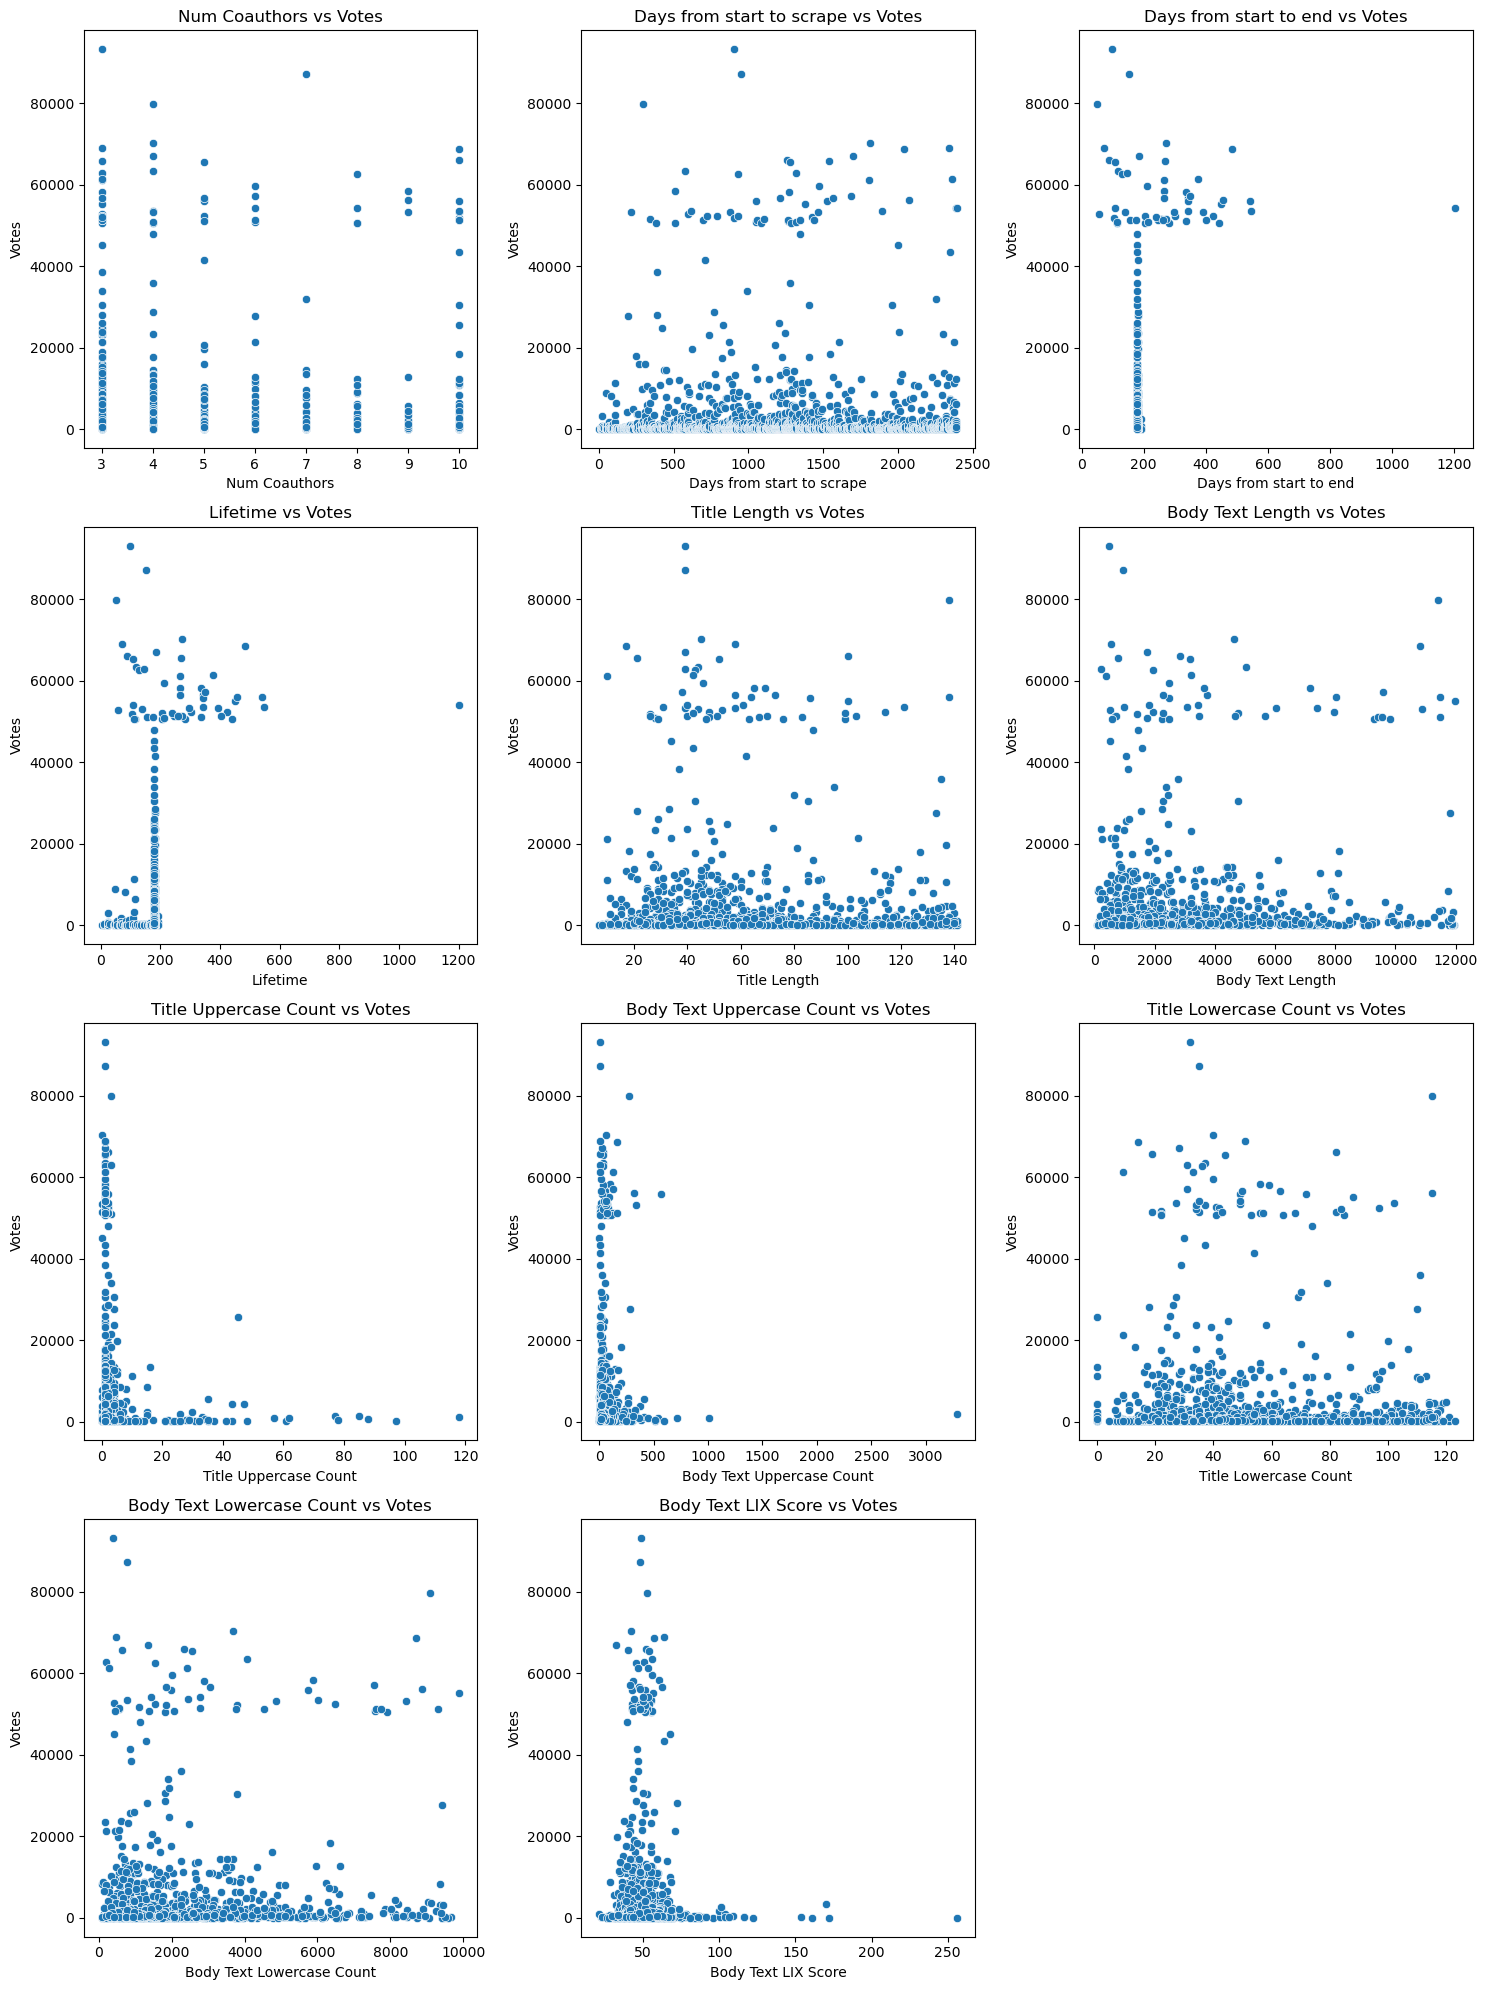

In [ ]:
# Call the function
scatterplot(df = df, target = target, features = num_cols)

## Step 3: Count Prediction with Machine Learning 

The scatterplots point to incorporation of polynomial features.

Create a function to calculate RMSE, MSE and MAE.

In [ ]:
def measure_error(y_train, y_train_pred, y_test, y_test_pred):
    # Calculate MSE
    mse_train = mean_squared_error(y_train, y_train_pred)
    mse_test = mean_squared_error(y_test, y_test_pred)
    
    # Calculate RMSE
    rmse_train = np.sqrt(mse_train)
    rmse_test = np.sqrt(mse_test)
    
    # Calculate MAE
    mae_train = mean_absolute_error(y_train, y_train_pred)
    mae_test = mean_absolute_error(y_test, y_test_pred)
    
    # Calculate MAPE
    mape_train = np.mean(np.abs((y_train - y_train_pred) / y_train))
    mape_test = np.mean(np.abs((y_test - y_test_pred) / y_test))
    
    # Return results in a dictionary
    return {
        'MSE_train': mse_train,
        'RMSE_train': rmse_train,
        'MAE_train': mae_train,
        'MAPE_train': mape_train,
        'MSE_test': mse_test,
        'RMSE_test': rmse_test,
        'MAE_test': mae_test,
        'MAPE_test': mape_test
    }

Use SKlearn to split the data and define lambdas for regularisation. 

In [ ]:
# Define target and features
log_y = log_target
y = target
X = df

# Split into development and test data
X_train, X_test, y_train, y_test, log_y_train, log_y_test = train_test_split(X, y, log_y, test_size=test_size_globale, random_state=random_state)

# Define lambdas
lambdas = np.logspace(-2, 2, 12)

Preprocess the DataFrame for SKlearn.

In [ ]:
# Create preprocessors

# For linear and poisson regressions
cat_pre = OneHotEncoder(handle_unknown='ignore')
num_pre = StandardScaler()

# For polynomial regression
cat_pre_pol = OneHotEncoder(handle_unknown='ignore')
num_pre_pol = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', StandardScaler())
])

# Create transformer
preprocessor = ColumnTransformer([('one-hot-encoder', cat_pre, cat_cols),
                         ('standard_scaler', num_pre, num_cols)])

# Create transformer
preprocessor_pol = ColumnTransformer([
    ('one-hot-encoder', cat_pre_pol, cat_cols),
    ('polynomial_scaler', num_pre_pol, num_cols)
]) 


Create pipeline for poisson regression, implement gridsearch cross-validation and find optimal hyperparameter.

In [ ]:
# OLS (Ordinary Least Squares) setup
mlr_pol_OLS_pipe = make_pipeline(
    preprocessor,
    LinearRegression(fit_intercept=False)
)

# Use GridSearchCV for finding the best model with cross-validation (although it's not necessary for OLS)
gs_OLS = GridSearchCV(
    estimator=mlr_pol_OLS_pipe, 
    param_grid={},  # Empty grid since OLS has no hyperparameters to tune
    scoring='neg_mean_squared_error', 
    cv=10, 
    n_jobs=-1
)

# OLS (Ordinary Least Squares) setup with polynomial features
mlr_pol_OLS_pipe = make_pipeline(
    preprocessor_pol,
    LinearRegression(fit_intercept=False)
)

# Use GridSearchCV for finding the best model with cross-validation (although it's not necessary for OLS)
gs_OLS_pol = GridSearchCV(
    estimator=mlr_pol_OLS_pipe, 
    param_grid={},  # Empty grid since OLS has no hyperparameters to tune
    scoring='neg_mean_squared_error', 
    cv=10, 
    n_jobs=-1
)


# LASSO preprocessesor pipeline
mlr_L1_pipe = make_pipeline(preprocessor,
                            Lasso(fit_intercept=False,
                            random_state=random_state,
                            max_iter=max_iter))

# Use GridSearch CV for finding optimal hyperparameter
gs_LASSO_pre = GridSearchCV(estimator=mlr_L1_pipe, 
                  param_grid=[{'lasso__alpha':lambdas}], 
                  scoring='neg_mean_squared_error', 
                  cv=10, 
                  n_jobs=-1)

# LASSO preprocessor
mlr_pol_L1_pipe = make_pipeline(preprocessor_pol,
                            Lasso(fit_intercept=False, 
                            random_state=random_state,
                            max_iter=max_iter,
                            tol=1e-4))

# Use GridSearchCV for finding optimal hyperparameter
gs_LASSO = GridSearchCV(estimator=mlr_pol_L1_pipe, 
                  param_grid=[{'lasso__alpha':lambdas}], 
                  scoring='neg_mean_squared_error', 
                  cv=10, 
                  n_jobs=-1)


# POISSON REGRESSION, GLM

# Create pipeline
pois_pipe = make_pipeline(preprocessor,
                         PoissonRegressor(fit_intercept=False, 
                                          max_iter=max_iter))

# Use GridSearchCV for finding optimal hyperparameter
gs_poisson = GridSearchCV(estimator=pois_pipe, 
                  param_grid={'poissonregressor__alpha': lambdas} , 
                  scoring='neg_mean_squared_error', 
                  cv=10, 
                  n_jobs=-1)

# Create pipeline
pois_pipe = make_pipeline(preprocessor_pol,
                         PoissonRegressor(fit_intercept=False, 
                                          max_iter=max_iter))

# Use GridSearchCV for finding optimal hyperparameter
gs_poisson_pol = GridSearchCV(estimator=pois_pipe, 
                  param_grid={'poissonregressor__alpha': lambdas} , 
                  scoring='neg_mean_squared_error', 
                  cv=10, 
                  n_jobs=-1)

In [ ]:
# Fitting models
fitted_models = {
    "OLS": gs_OLS.fit(X_train, y_train).best_estimator_,
    "LASSO": gs_LASSO_pre.fit(X_train, y_train).best_estimator_,
    "Poisson": gs_poisson.fit(X_train, y_train).best_estimator_,
    "OLS Polynomial Features": gs_OLS_pol.fit(X_train, y_train).best_estimator_,
    "LASSO Polynomial Features": gs_LASSO.fit(X_train, y_train).best_estimator_,
    "Poisson Polynomial Features": gs_poisson_pol.fit(X_train, y_train).best_estimator_
}

# Collect predictions for both training and test datasets
model_results = [
    (
        model_name,  # Reporting model name
        y_train,  # Actual training labels
        model.predict(X_train),  # Predicted training labels
        y_test,  # Actual test labels
        model.predict(X_test)  # Predicted test labels
    )
    for model_name, model in fitted_models.items()
]


# Summarize metrics based on model_results and include model name
summary_matrix = [
    {
        'Model': model_name,
        **measure_error(y_train, y_train_pred, y_test, y_test_pred)
    }
    for model_name, y_train, y_train_pred, y_test, y_test_pred in model_results
]


# Convert into dataframe
summary_df = pd.DataFrame(summary_matrix)


# Display the combined DataFrame
summary_df


/opt/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.302e+10, tolerance: 1.378e+07
  model = cd_fast.enet_coordinate_descent(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.101e+10, tolerance: 1.304e+07
  model = cd_fast.enet_coordinate_descent(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.591e+10, toler

,Model,MSE_train,RMSE_train,MAE_train,MAPE_train,MSE_test,RMSE_test,MAE_test,MAPE_test
0,OLS,7.876763e+07,8875.113011,4080.283439,19.656199,1.258594e+08,11218.709716,4746.142466,16.008647
1,LASSO,8.013455e+07,8951.790138,3953.649467,19.096387,1.226502e+08,11074.755719,4547.131623,15.287214
2,Poisson,8.143688e+07,9024.238258,3900.229596,18.255675,1.386882e+08,11776.595058,4670.831928,14.141246
3,OLS Polynomial Features,6.488535e+07,8055.144043,3734.979859,18.660243,1.661396e+08,12889.513465,5239.378822,17.602985
4,LASSO Polynomial Features,7.814625e+07,8840.036601,3885.636501,18.733902,1.220031e+08,11045.501959,4569.812602,15.307350
5,Poisson Polynomial Features,6.920599e+07,8319.013808,3586.832401,16.904851,1.469657e+08,12122.939623,4749.931252,14.191770


In [ ]:
# Filtering out data for LaTeX displaying
df_table_export = summary_df.drop(columns=["MSE_train", "MAE_train", "MSE_test", "MAE_test", "MSE_train", "MAE_train", "MSE_test", "MAE_test"]).apply(lambda x: round(x, 2))

# Exporting summary_matrix as csv
df_table_export.to_csv('Table_Results.csv', index=False)
df_table_export

,Model,RMSE_train,MAPE_train,RMSE_test,MAPE_test
0,OLS,8875.11,19.66,11218.71,16.01
1,LASSO,8951.79,19.10,11074.76,15.29
2,Poisson,9024.24,18.26,11776.60,14.14
3,OLS Polynomial Features,8055.14,18.66,12889.51,17.60
4,LASSO Polynomial Features,8840.04,18.73,11045.50,15.31
5,Poisson Polynomial Features,8319.01,16.90,12122.94,14.19


## Step 4: Visualization

In [ ]:
# Extract model names and their corresponding test predictions
model_names = [result[0] for result in model_results]
test_predictions = [result[-1] for result in model_results]  # Far right element (y_test_pred)

# Create a DataFrame where each column corresponds to the predictions of a model
results_df = pd.DataFrame(test_predictions, index=model_names).T

# Display the transposed DataFrame
display(results_df)

,OLS,LASSO,Poisson,OLS Polynomial Features,LASSO Polynomial Features,Poisson Polynomial Features
0,6753.721788,6559.546430,3030.592829,7115.565531,6704.525943,2383.746033
1,105.047938,1051.487125,1412.114617,588.279872,969.571024,1180.303375
2,3103.741521,3632.176286,2758.496341,2899.304505,2782.608729,2131.946741
3,5844.056188,2348.313167,4560.211127,3468.547867,2506.436116,4084.597739
4,4208.678653,5281.472374,2613.624442,3706.474477,5150.790467,2736.883270
...,...,...,...,...,...,...
365,1139.695397,732.860594,608.154018,1793.831590,721.625413,692.771906
366,1188.855456,1479.407839,1039.922788,1608.844370,1641.788012,1429.995350
367,3286.359569,3809.303543,2882.484405,1466.934942,3149.386048,1743.685569
368,1362.864485,1811.128284,2328.767934,2503.078741,1876.760315,1659.005910


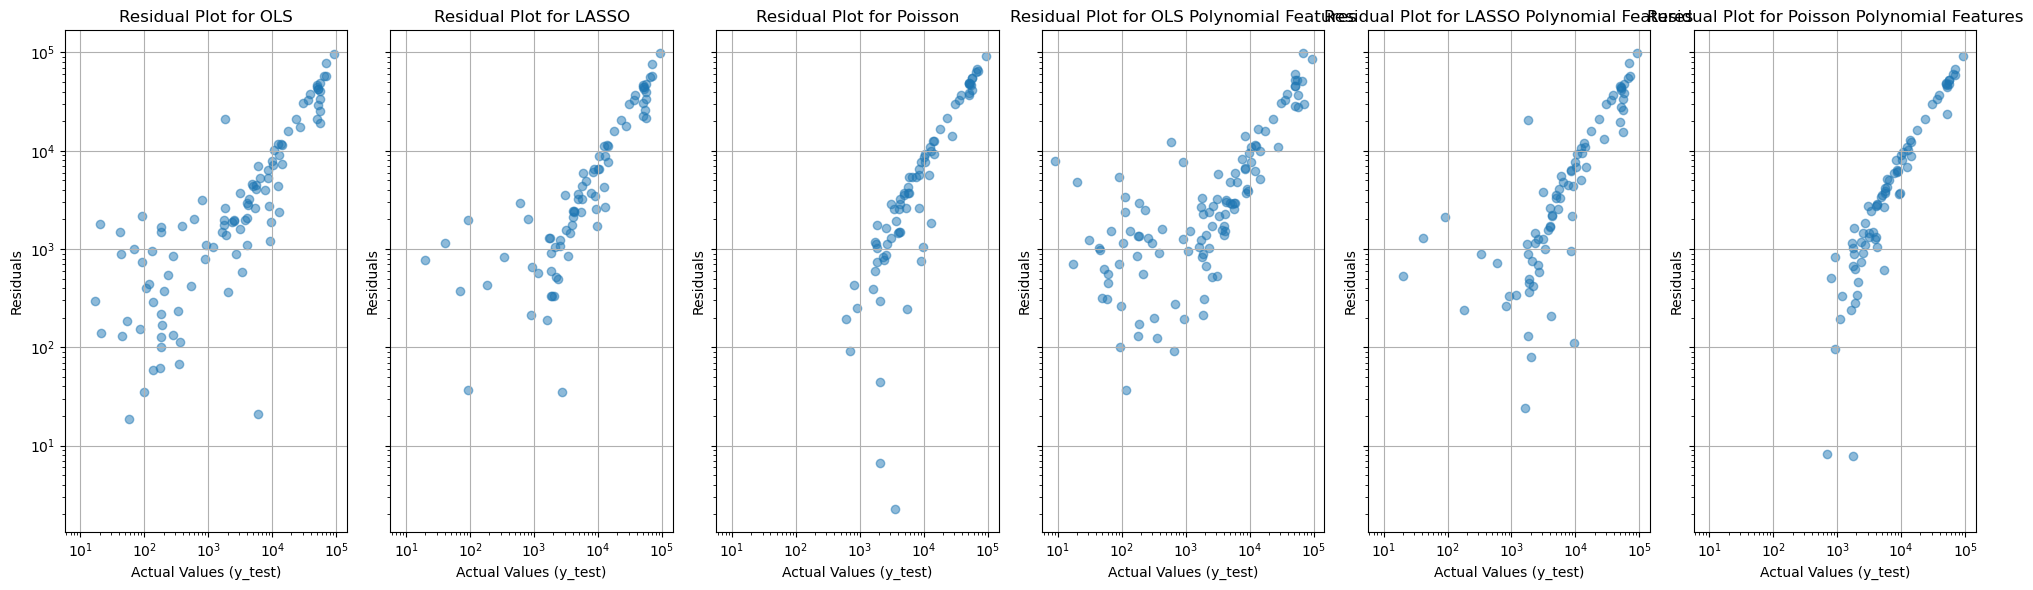

In [ ]:

# Set up a figure with subplots (adjust the size according to your needs)
fig, axes = plt.subplots(nrows=1, ncols=6, figsize=(20, 6), sharey=True)
# Plot residuals for each model in a subplot
for i, (model_name, _, _, y_test, y_test_pred) in enumerate(model_results):
    residuals = y_test - y_test_pred
    
    axes[i].scatter(y_test, residuals, alpha=0.5)
    axes[i].hlines(0, min(y_test), max(y_test), colors='red', linestyles='dashed')
    axes[i].set_xlabel('Actual Values (y_test)')
    axes[i].set_ylabel('Residuals')
    axes[i].set_title(f'Residual Plot for {model_name}')
    axes[i].grid(True)
    # Set x and y limits for each subplot
    #axes[i].set_xlim(0, 10000)  # Set x-axis limits
    #axes[i].set_ylim(-13000, 10000)  # Set y-axis limits

    # Set logarithmic scale for x and y axes
    axes[i].set_xscale('log')
    axes[i].set_yscale('log')


# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()

In [ ]:
naive_forecast = np.mean(np.sqrt((y_test-np.mean(y_train))**2))

print("RMSE of", naive_forecast)

RMSE of 5269.582338322095


This chunck is for visualization of the different predictions

/var/folders/11/qqy62xvx65vfhq7xdg4_h5qm0000gn/T/ipykernel_36384/2551986328.py:33: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  axes[i].set_ylim(0, 100000)


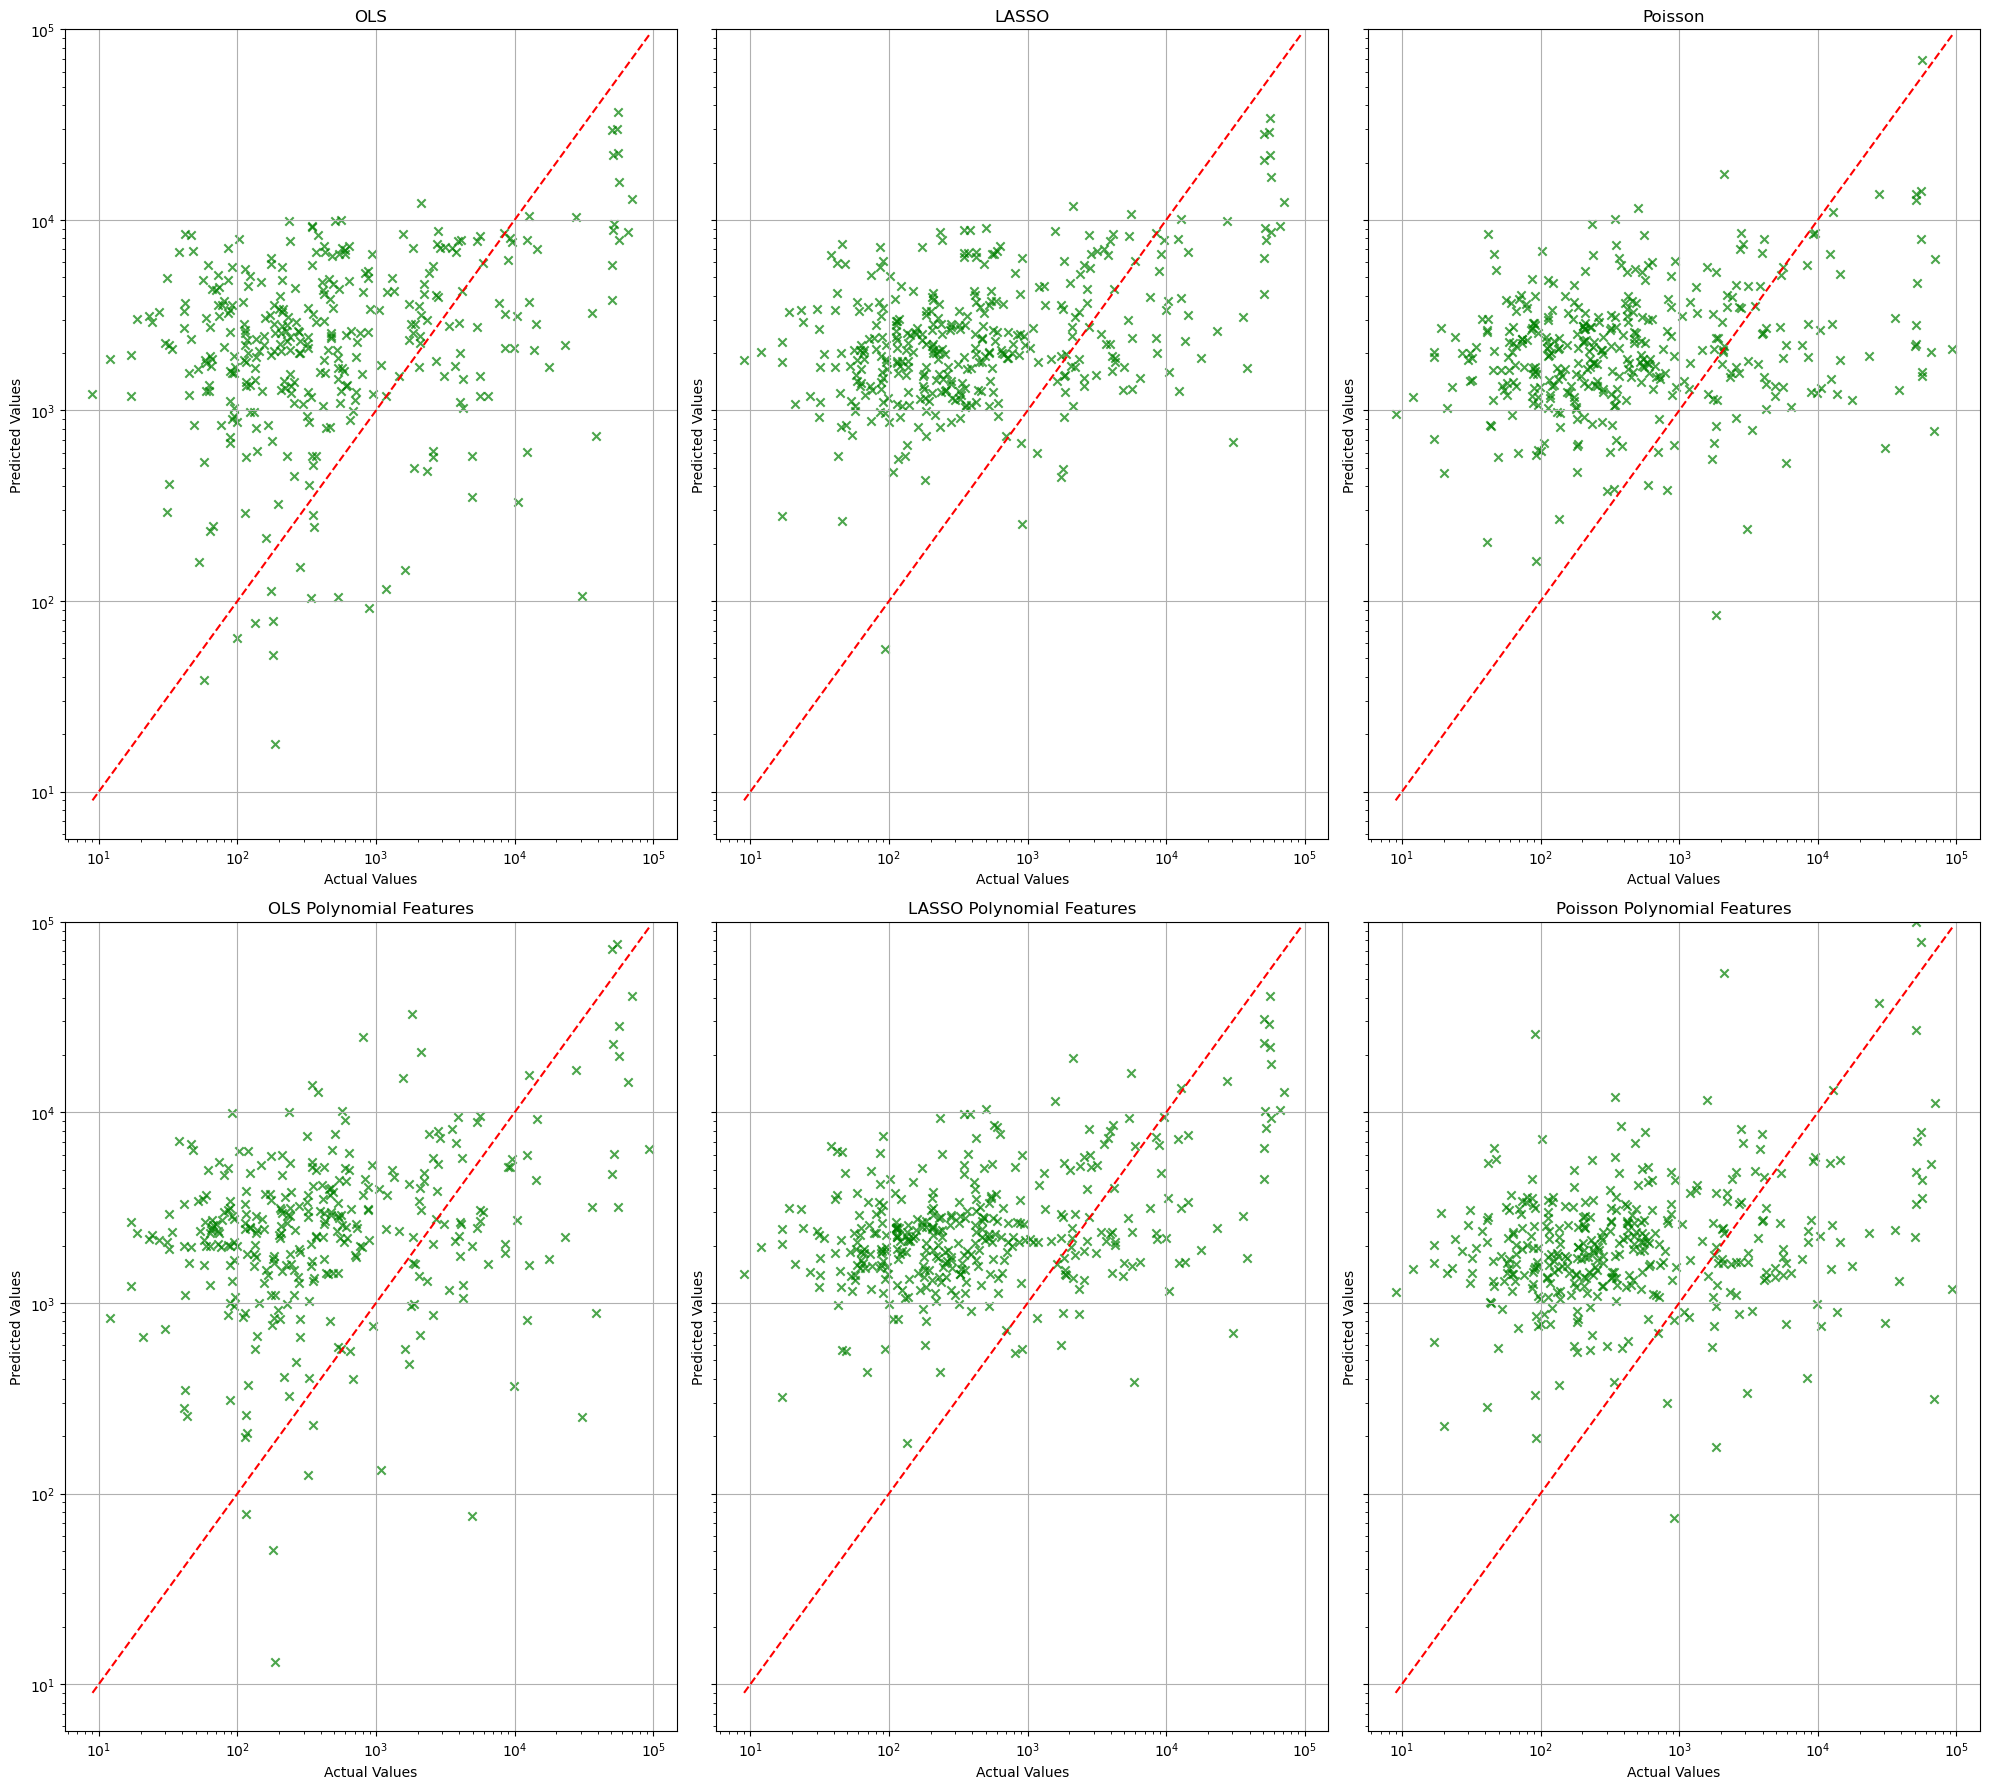

In [ ]:
# Set up a figure with subplots (adjust the size according to your needs)
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(20, 18), sharey=True)  # Adjust figsize for more space

# Flatten axes array to make it easier to index
axes = axes.flatten()

# Plot actual vs. predicted values for each model in a subplot
for i, (model_name, _, _, y_test, y_test_pred) in enumerate(model_results):
    if i >= len(axes):
        break  # Ensure we don't try to access an axis that doesn't exist

    # Scatter plot: Actual values on x-axis, Predicted values on y-axis
    axes[i].scatter(y_test, y_test_pred, alpha=0.7, marker='x', color='green')

    # Add a diagonal line to indicate perfect predictions
    axes[i].plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')

    # Set labels and title for each subplot
    axes[i].set_xlabel('Actual Values')
    axes[i].set_ylabel('Predicted Values')
    axes[i].set_title(f'{model_name}')

    # Add grid to each subplot
    axes[i].grid(True)

    # Set logarithmic scale for x and y axes
    axes[i].set_xscale('log')
    axes[i].set_yscale('log')

    # Set x and y limits for each subplot (uncomment and set appropriate limits if needed)

    #axes[i].set_xlim(0.1, 10000)  
    axes[i].set_ylim(0, 100000)

# Adjust layout to prevent overlapping
plt.tight_layout()

# Show the plot
plt.show()


In [ ]:
# Generate learning curve data LASSO POLYNOMIAL FEATURES
train_sizes_LASSO_pol, train_scores_LASSO_pol, valid_scores_LASSO_pol = learning_curve(
    gs_LASSO_pre, X_train, y_train, cv=10, scoring='neg_mean_squared_error', n_jobs=-1,
    random_state=random_state, train_sizes = np.linspace(0.1, 1.0, 10)
)

/opt/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.240e+06, tolerance: 1.237e+06
  model = cd_fast.enet_coordinate_descent(


In [ ]:
# Generate learning curve data OLS
train_sizes_OLS, train_scores_OLS, valid_scores_OLS = learning_curve(
    gs_OLS, X_train, y_train, cv=10, scoring='neg_root_mean_squared_error', n_jobs=-1,
    random_state=random_state, train_sizes = np.linspace(0.1, 1.0, 4)
)

# Generate learning curve data LASSO
train_sizes_LASSO, train_scores_LASSO, valid_scores_LASSO = learning_curve(
    gs_LASSO, X_train, y_train, cv=10, scoring='neg_mean_squared_error', n_jobs=-1,
    random_state=random_state, train_sizes = np.linspace(0.1, 1.0, 4)
)

# Generate learning curve data LASSO POLYNOMIAL FEATURES
train_sizes_LASSO_pre, train_scores_LASSO_pre, valid_scores_LASSO_pre = learning_curve(
    gs_LASSO_pre, X_train, y_train, cv=10, scoring='neg_mean_squared_error', n_jobs=-1,
    random_state=random_state, train_sizes = np.linspace(0.1, 1.0, 4)
)

# Generate learning curve data POISSON
train_sizes_poisson, train_scores_poisson, valid_scores_poisson = learning_curve(
    gs_poisson, X_train, y_train, cv=10, scoring='neg_mean_squared_error', n_jobs=-1,
    random_state=random_state, train_sizes = np.linspace(0.1, 1.0, 4)
)

# Generate learning curve data POISSON POLYNOMIAL FEATURES
train_sizes_poisson_pol, train_scores_poisson_pol, valid_scores_poisson_pol = learning_curve(
    gs_poisson_pol, X_train, y_train, cv=10, scoring='neg_mean_squared_error', n_jobs=-1,
    random_state=random_state, train_sizes = np.linspace(0.1, 1.0, 4)
)

/opt/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.616e+07, tolerance: 1.040e+05
  model = cd_fast.enet_coordinate_descent(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.880e+07, tolerance: 1.053e+05
  model = cd_fast.enet_coordinate_descent(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.576e+08, toler

KeyboardInterrupt: 

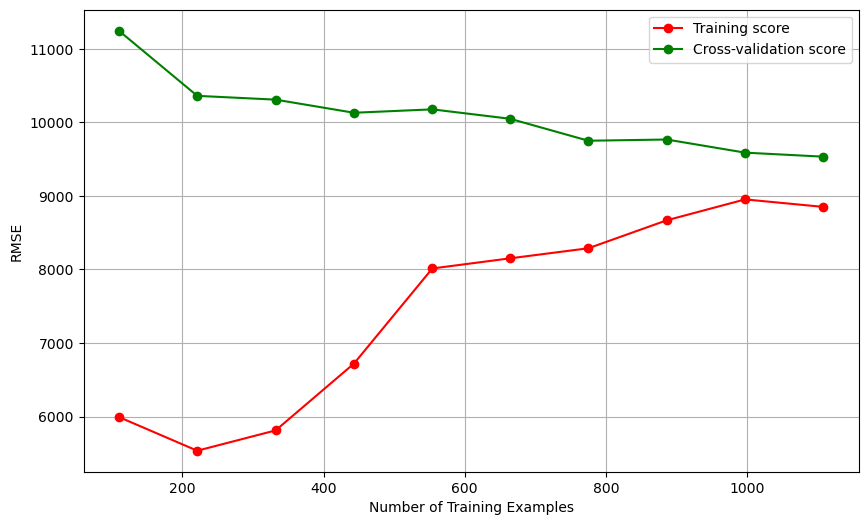

In [ ]:
# Convert negative MSE to RMSE for plotting
train_scores_mean = np.sqrt(-train_scores_LASSO_pol.mean(axis=1))
train_scores_std = np.sqrt(train_scores_LASSO_pol.std(axis=1))
valid_scores_mean = np.sqrt(-valid_scores_LASSO_pol.mean(axis=1))
valid_scores_std = np.sqrt(valid_scores_LASSO_pol.std(axis=1))

# Plot the learning curve with the actual number of observations on the x-axis
plt.figure(figsize=(10, 6))
plt.plot(train_sizes_LASSO_pol, train_scores_mean, 'o-', color="r", label="Training score")
plt.plot(train_sizes_LASSO_pol, valid_scores_mean, 'o-', color="g", label="Test score")

# Optionally, fill between the mean +- std (confidence interval)
# plt.fill_between(actual_train_sizes, train_scores_mean - train_scores_std,
#                  train_scores_mean + train_scores_std, alpha=0.1, color="r")
# plt.fill_between(actual_train_sizes, valid_scores_mean - valid_scores_std,
#                  valid_scores_mean + valid_scores_std, alpha=0.1, color="g")

# Set plot labels and title
plt.xlabel("Training Examples")
plt.ylabel("RMSE")
plt.legend(loc="best")
plt.grid(True)
plt.show()


## Part 3: Logarithmic model alternatives

In [ ]:
log_fitted_models = {
    "log LASSO": gs_LASSO_pre.fit(X_train, log_y_train).best_estimator_,
    "log LASSO Polynomial Features": gs_LASSO.fit(X_train, log_y_train).best_estimator_,
    "log Poisson": gs_poisson.fit(X_train, log_y_train).best_estimator_
}


log_model_results = [
    (
        model_name,  # Reporting model name
        log_y_train,  # Actual training labels
        model.predict(X_train),  # Predicted training labels
        log_y_test,  # Actual test labels
        model.predict(X_test)  # Predicted test labels
    )
    for model_name, model in log_fitted_models.items()
]

log_summary_matrix = [
    {
        'Model': model_name,
        **measure_error(y_train, y_train_pred, y_test, y_test_pred)
    }
    for model_name, y_train, y_train_pred, y_test, y_test_pred in log_model_results
]

In [ ]:
# Extract model names and their corresponding test predictions
log_model_names = [result[0] for result in log_model_results]
log_test_predictions = [result[-1] for result in log_model_results]  # Far right element (y_test_pred)

# Create a DataFrame where each column corresponds to the predictions of a model
log_results_df = pd.DataFrame(log_test_predictions, index=log_model_names).T

# Display the transposed DataFrame
display(log_results_df)

,log LASSO,log LASSO Polynomial Features,log Poisson
0,2.893973,2.587487,2.930784
1,2.336876,2.386912,2.228936
2,2.499030,2.451339,2.458078
3,2.764123,2.580631,2.746072
4,2.684807,2.340792,2.667825
...,...,...,...
612,2.680218,2.587492,2.677863
613,2.635726,2.572916,2.660913
614,2.480089,2.501953,2.464949
615,2.708678,2.496390,2.575094


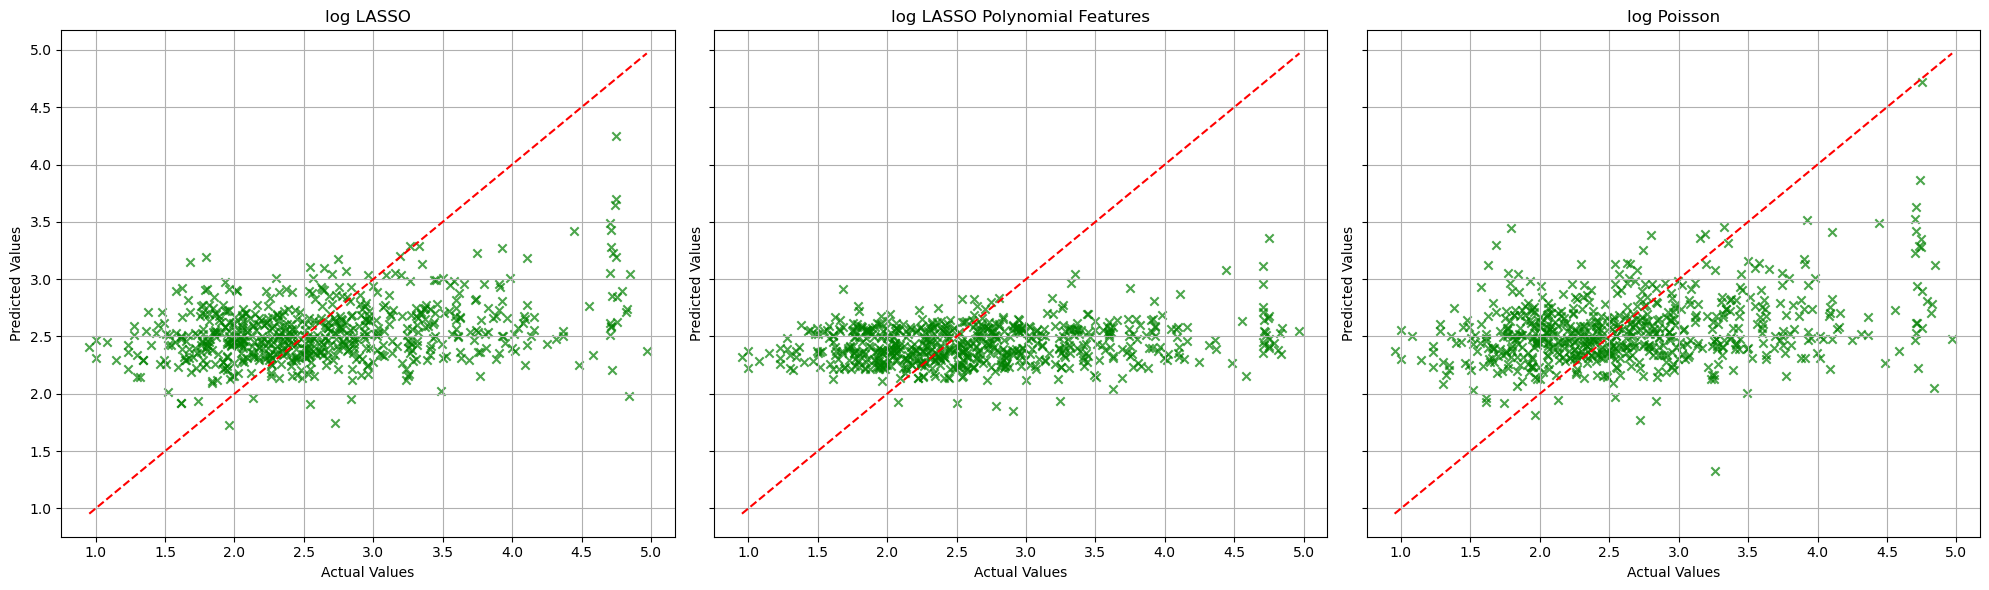

In [ ]:
# Set up a figure with subplots (adjust the size according to your needs)
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(20, 6), sharey=True)

# Plot actual vs. predicted values for each model in a subplot
for i, (model_name, _, _, y_test, y_test_pred) in enumerate(log_model_results):
    
    # Scatter plot: Actual values on x-axis, Predicted values on y-axis
    axes[i].scatter(y_test, y_test_pred, alpha=0.7, marker='x', color='green')

    # Add a diagonal line to indicate perfect predictions
    axes[i].plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')

    # Set labels and title for each subplot
    axes[i].set_xlabel('Actual Values')
    axes[i].set_ylabel('Predicted Values')
    axes[i].set_title(f'{model_name}')

    # Add grid to each subplot
    axes[i].grid(True)

    # Set x and y limits for each subplot
    #axes[i].set_xlim(0, 10000)  # Set x-axis limits
    #axes[i].set_ylim(0, 10000)  # Set y-axis limits


# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()


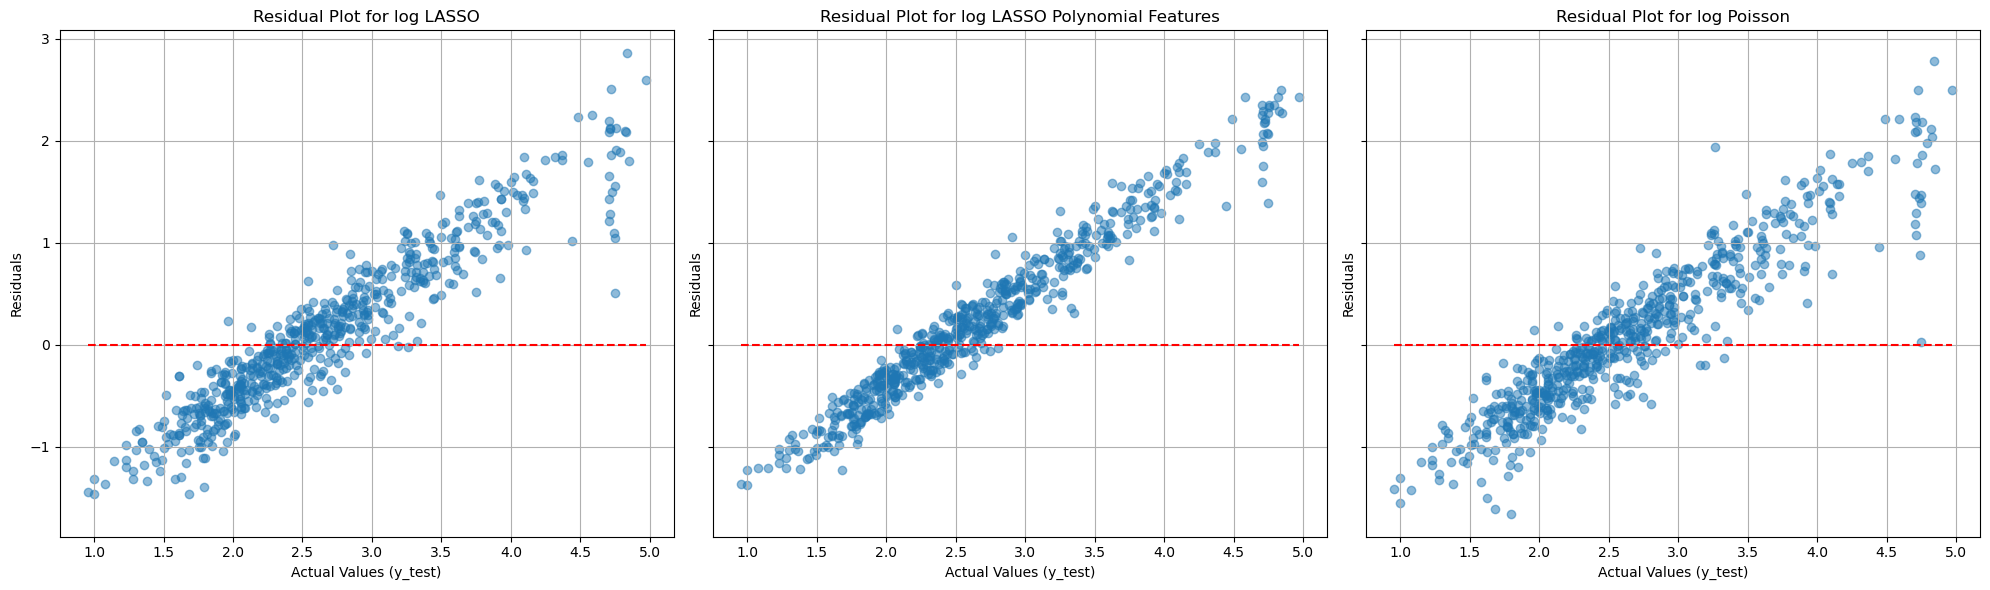

In [ ]:

# Set up a figure with subplots (adjust the size according to your needs)
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(20, 6), sharey=True)

# Plot residuals for each model in a subplot
for i, (model_name, _, _, y_test, y_test_pred) in enumerate(log_model_results):
    residuals = y_test - y_test_pred  # Assuming y_test_pred is already log-transformed
    
    axes[i].scatter(y_test, residuals, alpha=0.5)
    axes[i].hlines(0, min(y_test), max(y_test), colors='red', linestyles='dashed')
    axes[i].set_xlabel('Actual Values (y_test)')
    axes[i].set_ylabel('Residuals')
    axes[i].set_title(f'Residual Plot for {model_name}')
    axes[i].grid(True)

    # Optional: Set x and y limits for each subplot
    #axes[i].set_xlim(0, 10000)  # Set x-axis limits if needed
    #axes[i].set_ylim(-13000, 10000)  # Set y-axis limits if needed

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()

## Load modules